# DBSCAN Clustering with Python

## Import Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

## Create some Data

In [52]:
from sklearn.datasets import make_circles

In [111]:
# Create Data
data = make_circles(
    n_samples=200, factor=0.5, noise=0.05, random_state=0
)

In [112]:
# data
data[0][0:5]

array([[ 0.4013312 ,  0.88583093],
       [-0.14152176, -0.55959569],
       [ 0.40657379,  0.20692844],
       [ 0.96980084, -0.23250101],
       [ 0.06316851, -0.52396848]])

In [113]:
# actual cluster group
data[1][0:5]

array([0, 1, 1, 0, 1])

# (Optional) Scaler and Inverse Scaler

In [114]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# scaler.fit(data[0])

# trans_data = scaler.transform(data[0])
# print(trans_data[0:5,])

# org_data = scaler.inverse_transform(trans_data)
# print(org_data[0:5,])

## Visualize Data

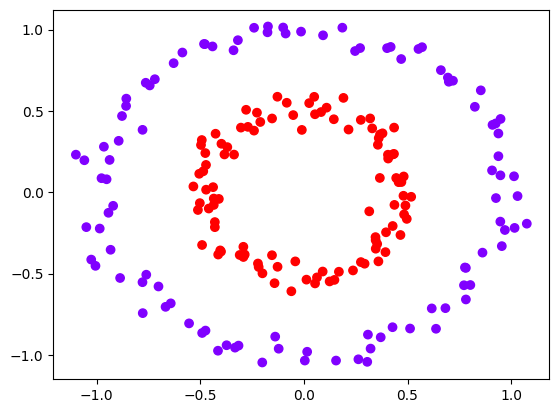

In [115]:
plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

## Creating the Clusters

In [116]:
from sklearn.cluster import DBSCAN

In [117]:
db = DBSCAN(eps=0.2, min_samples=5).fit(data[0])

In [118]:
labels = db.labels_
labels

array([0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1])

In [119]:
# -1 in labels represents noise points (outliers) that don't belong to any cluster
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print('Estimated number of clusters: %d' % n_clusters_)

Estimated number of clusters: 2


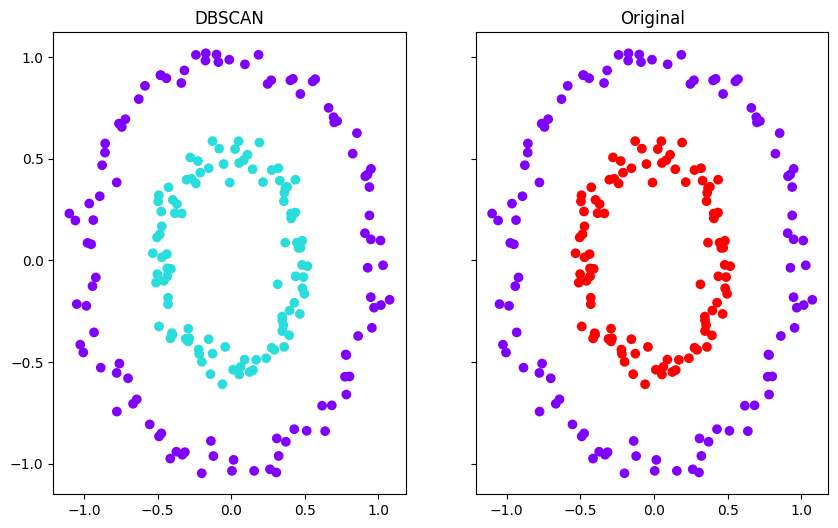

In [120]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True,figsize=(10,6))

ax1.set_title('DBSCAN')
# color noise points light gray, and cluster members using a rainbow colormap
colors = ['lightgray' if lab == -1 else plt.cm.rainbow(lab / 3.0) for lab in labels]
ax1.scatter(data[0][:,0], data[0][:,1], c=colors)

ax2.set_title("Original")
ax2.scatter(data[0][:,0], data[0][:,1], c=data[1], cmap='rainbow')

You should note, the colors are meaningless in reference between the two plots.